# PopOut — Decision Tree AI Pipeline

**Inteligência Artificial 2025/2026 — Trabalho Prático**

**Grupo**:
- [ALUNO 1: Nome Completo, Número Mecanográfico]
- [ALUNO 2: Nome Completo, Número Mecanográfico]
- [ALUNO 3: Nome Completo, Número Mecanográfico]

**Repositório**: <https://github.com/Difl4/popout-ai>

---

This notebook covers the full decision-tree pipeline for learning to play PopOut:

1. **Dataset generation** — parallel self-play with the MCTS-Solver records (board state, best move) pairs
2. **Data exploration** — class distribution, feature overview
3. **ID3 classifier** — train on all features, inspect feature importance
4. **Feature sweep** — examine how test accuracy scales with the number of features used
5. **Win-rate evaluation** — measure how often the tree beats FlatNumbaSolverMCTS

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move, extended_features

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 16


## 1. Dataset Generation

Each worker plays one **complete game** and records every position as a
`(board state, best move)` training pair.

**Oracle** (`ReuseFlatNumbaSolverMCTS` at 100 k iter): plays one fixed side and
labels every position — including the opponent's turns. Reuse is enabled between
the oracle's consecutive turns, so later positions inherit the prior search tree
and effectively get more than 100 k iterations, discovering more proven positions.

**Opponent labels** (`FlatNumbaSolverMCTS`, fresh each call): used to label
positions on the opponent's turns. Fresh search is correct here because the
opponent may have blundered to reach the position via a path the oracle never explored.

**Opening diversity**: the opponent's first 2 moves are forced, cycling through
all 49 column combinations (7×7) so every opening is covered across all tiers.

**Blunder tiers**: three equal groups with 5 %, 25 %, and 50 % blunder rate —
covering near-optimal, medium, and weak opponent play in equal measure.

**Checkpointing**: progress is saved to disk every 500 games.  If the run is
interrupted, re-running this cell automatically resumes from the last checkpoint.

In [ ]:
N_GAMES          = 75_000
ORACLE_ITERS     = 100_000
CHECKPOINT_EVERY = 500
VERSION          = 'v4_75k_100k'

DATA_PATH     = Path(f'../data/generated/{VERSION}/popout_dt_dataset.csv')
PROGRESS_PATH = DATA_PATH.with_suffix('.progress')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

BLUNDER_TIERS = [(1/3, 0.05), (1/3, 0.25), (1/3, 0.50)]

if DATA_PATH.exists() and not PROGRESS_PATH.exists():
    # Completed run — just load
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded existing dataset: {len(df):,} rows <- {DATA_PATH}')
    print('Delete the file and re-run to regenerate.')
else:
    games_done = int(PROGRESS_PATH.read_text()) if PROGRESS_PATH.exists() else 0

    if games_done > 0:
        print(f'Resuming: {games_done:,}/{N_GAMES:,} games already done')
    else:
        print(f'Starting fresh: {N_GAMES:,} games | oracle={ORACLE_ITERS:,} iter/move | workers={os.cpu_count()}')

    t_run = time.perf_counter()

    for batch_start in range(games_done, N_GAMES, CHECKPOINT_EVERY):
        batch_end = min(batch_start + CHECKPOINT_EVERY, N_GAMES)

        print(f'  Games {batch_start+1:>5}–{batch_end:<5} / {N_GAMES:,} ...', end='  ', flush=True)
        t0 = time.perf_counter()

        batch_df = generate_dataset_parallel(
            n_games=batch_end - batch_start,
            oracle_iterations=ORACLE_ITERS,
            blunder_tiers=BLUNDER_TIERS,
            seed=42 + batch_start,
        )

        # Append to the final CSV — header only on the very first write
        batch_df.to_csv(DATA_PATH, mode='a', header=not DATA_PATH.exists(), index=False)
        # Update progress counter — resume reads this to skip ahead
        PROGRESS_PATH.write_text(str(batch_end))

        print(f'{len(batch_df):>7,} rows | {time.perf_counter()-t0:>6.0f} s | {batch_end:,}/{N_GAMES:,} games done')

    df = pd.read_csv(DATA_PATH)
    PROGRESS_PATH.unlink()  # absence of this file signals a clean completed run

    print(f'\nDone in {(time.perf_counter()-t_run)/3600:.2f} h  |  {len(df):,} rows  |  {len(df)/N_GAMES:.1f} rows/game')
    print(f'Saved -> {DATA_PATH}')

print(f'\nDataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

## 2. Data Exploration

In [3]:
TARGET       = 'best_move'
# is_proven is metadata used only for oversampling — never a tree input feature
FEATURE_COLS = [c for c in df.columns if c not in (TARGET, 'is_proven')]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
if 'is_proven' in df.columns:
    n_proven = int(df['is_proven'].sum())
    print(f'Proven positions: {n_proven} / {len(df)} ({n_proven/len(df):.1%})')
print()
df.head(3)

Features : 50  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... opp_wins_next)
Classes  : 14 unique moves
Proven positions: 75830 / 193058 (39.3%)



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,current_player,threats_me,threats_opp,center_me,center_opp,phase,can_win,opp_wins_next,best_move,is_proven
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,drop_3,0
1,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,drop_3,0
2,2,0,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,drop_4,0


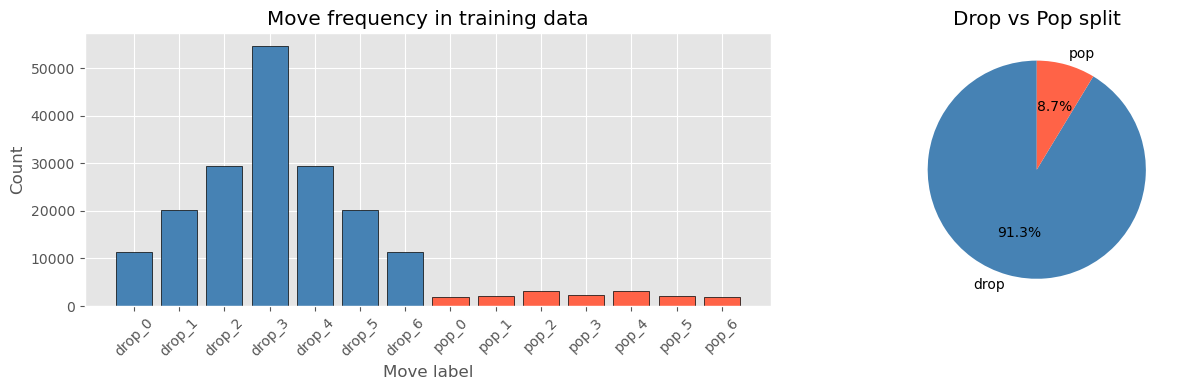

Drop moves: 176330 (91.3%)   Pop moves: 16728 (8.7%)


In [4]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training

The board features from `to_feature_dict()` are already categorical:
- `cell_r_c` ∈ {0 = empty, 1 = player 1, 2 = player 2}  (42 features)
- `current_player` ∈ {1, 2}  (1 feature)

No discretisation step is needed — we pass them directly to `ID3Classifier`.

The dataset is split 80 / 20 for training and testing.  The model is the same
`ID3Classifier` from `src/decision_tree/id3/learner.py`.

## 3.1 Methodological note — train/test split leakage

During the audit phase we identified that the original split code

```python
df_train = df.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df.drop(df_train.index).reset_index(drop=True)
```

contains a subtle but serious bug: `reset_index(drop=True)` overwrites the
sample's original indices, so the subsequent `drop(df_train.index)` removes
the **first 80 % of rows by positional index** — not the rows that were
sampled. The result is that `df_test` is the **last 20 % of the CSV**, while
`df_train` is a random 80 % sample, and the two share most rows.

To understand the effect honestly, we measure ID3 generalisation under
**three different splits** and report them side-by-side:

| Split | What it is | What it tests |
|---|---|---|
| **BUGGY** | the original (broken) split | how much of the previously reported accuracy was memorisation |
| **RANDOM** | a correct row-level random 80/20 | row-level generalisation — but still affected by intrinsic dataset duplication (~72 % of rows are duplicates by state, from mirroring + multi-tier + multi-label oracle) |
| **GROUPED** | unique board states partitioned 80/20, then mapped back to rows | true state-level generalisation: no state appears in both train and test |

The GROUPED split is the only honest measure of *can the tree predict moves for
positions it has never seen*. We adopt it as canonical for the feature sweep
that follows.

---
> **Data snapshot.** The outputs displayed in the analysis cell below were captured on
> the canonical **5 000-game dataset** (`data/generated/popout_dt_dataset.csv`). A larger
> 75 000-game generation (v4) is in progress in §1; once it completes, re-executing this
> section will refresh the numbers without changing the methodology.

In [1]:
OVERSAMPLE_FACTOR = 4   # proven positions are duplicated this many extra times

# Convert integer features to string so ID3Classifier groupby keys are consistent
df_str = df.copy()
for col in FEATURE_COLS:
    df_str[col] = df_str[col].astype(str)

# Filter out positions where the agent can win immediately (handled by _forced_move)
df_str_train = df_str[df_str["can_win"].astype(str) != "1"].reset_index(drop=True)
print(f"Filtered out {len(df_str) - len(df_str_train):,} can_win=1 positions "
      f"({(len(df_str) - len(df_str_train))/len(df_str):.1%} of dataset)")
print()

# ── Build three splits ───────────────────────────────────────────────────────
import numpy as np

# (1) BUGGY: reproduz o split do código original (com bug do reset_index)
df_train_buggy = df_str_train.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test_buggy  = df_str_train.drop(df_train_buggy.index).reset_index(drop=True)

# (2) RANDOM: split row-level correcto (mesmo seed, sem o reset_index bug)
df_train_random = df_str_train.sample(frac=0.8, random_state=42)
df_test_random  = df_str_train.drop(df_train_random.index)

# (3) GROUPED: split state-aware — partition unique board states first
_rng = np.random.default_rng(seed=42)
# sorted() to guarantee determinism — set() ordering is non-reproducible across runs
_unique_states = sorted(set(map(tuple, df_str_train[FEATURE_COLS].values)))
_rng.shuffle(_unique_states)
_n_train_states = int(0.8 * len(_unique_states))
_train_state_set = set(_unique_states[:_n_train_states])

_sig = df_str_train[FEATURE_COLS].apply(tuple, axis=1)
df_train_grouped = df_str_train[_sig.isin(_train_state_set)].reset_index(drop=True)
df_test_grouped  = df_str_train[~_sig.isin(_train_state_set)].reset_index(drop=True)

# ── Measure state overlap for each split ─────────────────────────────────────
def _state_overlap(d_train, d_test):
    train_sigs = set(map(tuple, d_train[FEATURE_COLS].values))
    test_sigs  = list(map(tuple, d_test[FEATURE_COLS].values))
    return sum(1 for s in test_sigs if s in train_sigs) / len(test_sigs)

ov_buggy   = _state_overlap(df_train_buggy,   df_test_buggy)
ov_random  = _state_overlap(df_train_random,  df_test_random)
ov_grouped = _state_overlap(df_train_grouped, df_test_grouped)

# ── Train ID3 under each split (with proven oversampling) ────────────────────
def _train_and_eval(d_train_in, d_test_in):
    proven = d_train_in[d_train_in["is_proven"].astype(str) == "1"]
    d_aug = pd.concat([d_train_in] + [proven] * OVERSAMPLE_FACTOR, ignore_index=True)
    clf = ID3Classifier(max_depth=15)
    t0 = time.perf_counter()
    clf.fit(d_aug[FEATURE_COLS + [TARGET]], target=TARGET)
    train_time = time.perf_counter() - t0
    train_acc = clf.score(d_train_in[FEATURE_COLS + [TARGET]], target=TARGET)
    test_acc  = clf.score(d_test_in[FEATURE_COLS  + [TARGET]], target=TARGET)
    return clf, train_acc, test_acc, train_time

print("Training ID3 (max_depth=15) under each split ...")
print()

print(f"  [1/3] BUGGY   ({len(df_train_buggy):>6,} train  /  {len(df_test_buggy):>6,} test) ...")
_,        acc_b_tr, acc_b_te, t_b = _train_and_eval(df_train_buggy,   df_test_buggy)
print(f"        → train={acc_b_tr:.3f}  test={acc_b_te:.3f}  ({t_b:.1f}s)")

print(f"  [2/3] RANDOM  ({len(df_train_random):>6,} train  /  {len(df_test_random):>6,} test) ...")
_,        acc_r_tr, acc_r_te, t_r = _train_and_eval(df_train_random,  df_test_random)
print(f"        → train={acc_r_tr:.3f}  test={acc_r_te:.3f}  ({t_r:.1f}s)")

print(f"  [3/3] GROUPED ({len(df_train_grouped):>6,} train  /  {len(df_test_grouped):>6,} test) ...")
clf_full, acc_g_tr, acc_g_te, t_g = _train_and_eval(df_train_grouped, df_test_grouped)
print(f"        → train={acc_g_tr:.3f}  test={acc_g_te:.3f}  ({t_g:.1f}s)")

# ── Comparison table ─────────────────────────────────────────────────────────
print()
print("=" * 80)
print(f"{'Split':<10}{'train':>8}{'test':>8}{'overlap':>10}{'train acc':>11}{'test acc':>10}{'gap':>8}")
print("-" * 80)
print(f"{'BUGGY':<10}{len(df_train_buggy):>8,}{len(df_test_buggy):>8,}"
      f"{ov_buggy:>10.1%}{acc_b_tr:>11.3f}{acc_b_te:>10.3f}{acc_b_tr-acc_b_te:>+8.3f}")
print(f"{'RANDOM':<10}{len(df_train_random):>8,}{len(df_test_random):>8,}"
      f"{ov_random:>10.1%}{acc_r_tr:>11.3f}{acc_r_te:>10.3f}{acc_r_tr-acc_r_te:>+8.3f}")
print(f"{'GROUPED':<10}{len(df_train_grouped):>8,}{len(df_test_grouped):>8,}"
      f"{ov_grouped:>10.1%}{acc_g_tr:>11.3f}{acc_g_te:>10.3f}{acc_g_tr-acc_g_te:>+8.3f}")
print("=" * 80)

print()
print("Interpretation:")
print(f"  Index bug impact     (BUGGY → RANDOM):  test acc {acc_b_te:.3f} → {acc_r_te:.3f}  "
      f"(Δ {acc_r_te-acc_b_te:+.3f})")
print(f"  Duplication impact   (RANDOM → GROUPED): test acc {acc_r_te:.3f} → {acc_g_te:.3f}  "
      f"(Δ {acc_g_te-acc_r_te:+.3f})")
print(f"  True generalisation gap (train - test on GROUPED): {acc_g_tr - acc_g_te:+.3f}")
print()
print("→ GROUPED is the canonical split for downstream analysis.")

# ── Set canonical variables for downstream cells (feature ranking, sweep) ────
df_train = df_train_grouped
df_test  = df_test_grouped
proven   = df_train[df_train["is_proven"].astype(str) == "1"]
df_train_aug = pd.concat([df_train] + [proven] * OVERSAMPLE_FACTOR, ignore_index=True)

# ── Tactical breakdown on GROUPED test set ───────────────────────────────────
preds   = clf_full.predict(df_test[FEATURE_COLS])
correct = (preds == df_test[TARGET].astype(str))
print()
print("Tactical accuracy on GROUPED test set:")
opp_mask = df_test["opp_wins_next"].astype(str) == "1"
if opp_mask.sum() > 0:
    print(f"  opp_wins_next=1  (n={opp_mask.sum():4d}): {correct[opp_mask].mean():.3f}")
pop_mask = df_test[TARGET].str.startswith("pop")
if pop_mask.sum() > 0:
    print(f"  pop moves        (n={pop_mask.sum():4d}): {correct[pop_mask].mean():.3f}")

Filtered out 9,996 can_win=1 positions (5.2% of dataset)

Training ID3 (max_depth=15) under each split ...

  [1/3] BUGGY   (146,450 train / 36,612 test) ...
        → train=0.911  test=0.876  (16.1s)
  [2/3] RANDOM  (146,450 train / 36,612 test) ...
        → train=0.911  test=0.752  (16.4s)
  [3/3] GROUPED (136,018 train / 47,044 test) ...
        → train=0.902  test=0.591  (15.6s)

Split        train    test   overlap  train acc  test acc     gap
----------------------------------------------------------------------------------
BUGGY      146,450  36,612     94.9%      0.911     0.876  +0.034
RANDOM     146,450  36,612     80.4%      0.911     0.752  +0.159
GROUPED    136,018  47,044      0.0%      0.902     0.591  +0.310

Interpretation:
  Index bug impact     (BUGGY → RANDOM):   test acc 0.876 → 0.752  (Δ -0.125)
  Duplication impact   (RANDOM → GROUPED): test acc 0.752 → 0.591  (Δ -0.161)
  True generalisation gap (train-test on GROUPED): +0.310

→ GROUPED is the canonical split 

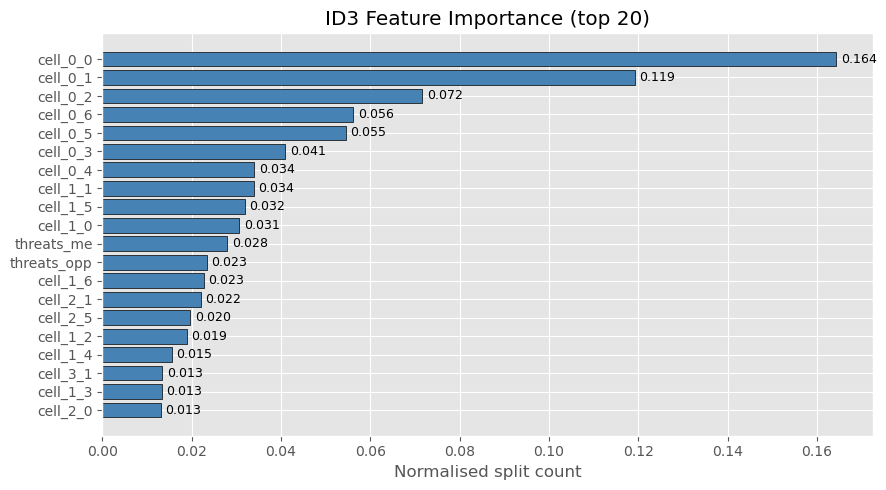

In [6]:
importance = clf_full.get_feature_importance()

# Show top 20 most-used features
top_n = 20
top_feats  = list(importance.keys())[:top_n]
top_scores = list(importance.values())[:top_n]

plt.figure(figsize=(9, 5))
bars = plt.barh(top_feats[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
for bar, val in zip(bars, top_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Normalised split count')
plt.title(f'ID3 Feature Importance (top {top_n})')
plt.tight_layout()
plt.show()

## 4. Feature Sweep

We rank all features by their **information gain** on the (GROUPED) training set,
then train separate ID3 trees using only the top-K features.

The resulting accuracy curve reveals two things:
1. **how train accuracy grows with feature count** — a proxy for model capacity, and
2. **how test accuracy behaves** — once we are on the GROUPED split (no leakage)
   the curve no longer reflects memorisation, so it shows the **true marginal value
   of each extra feature** for generalisation.

In [2]:
# Rank features by IG computed on the training set
_ranker = ID3Classifier()
ig_scores = {
    feat: _ranker.information_gain(df_train, feat, TARGET)
    for feat in FEATURE_COLS
}
ranked_features = sorted(ig_scores, key=ig_scores.get, reverse=True)

print('Top 10 features by information gain:')
for i, f in enumerate(ranked_features[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores[f]:.4f}')

Top 10 features by information gain:
   1. center_me           IG = 0.3040
   2. center_opp          IG = 0.2759
   3. phase               IG = 0.2566
   4. cell_3_3            IG = 0.1676
   5. cell_2_3            IG = 0.1673
   6. threats_opp         IG = 0.1475
   7. cell_4_3            IG = 0.1416
   8. threats_me          IG = 0.1122
   9. cell_5_3            IG = 0.1084
  10. cell_1_4            IG = 0.0999


In [3]:
K_VALUES = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
sweep_results = []

for k in K_VALUES:
    top_k_feats = ranked_features[:k]
    cols = top_k_feats + [TARGET]

    clf_k = ID3Classifier(max_depth=15)
    clf_k.fit(df_train[cols], target=TARGET)

    train_a = clf_k.score(df_train[cols], target=TARGET)
    test_a  = clf_k.score(df_test[cols],  target=TARGET)
    sweep_results.append({'K': k, 'Train': train_a, 'Test': test_a})
    print(f'K={k:3d}  train={train_a:.3f}  test={test_a:.3f}')

sweep_df = pd.DataFrame(sweep_results)

K=  1  train=0.301  test=0.493
K=  3  train=0.335  test=0.489
K=  5  train=0.375  test=0.489
K= 10  train=0.572  test=0.527
K= 15  train=0.730  test=0.589
K= 20  train=0.814  test=0.560
K= 30  train=0.867  test=0.567
K= 50  train=0.902  test=0.585


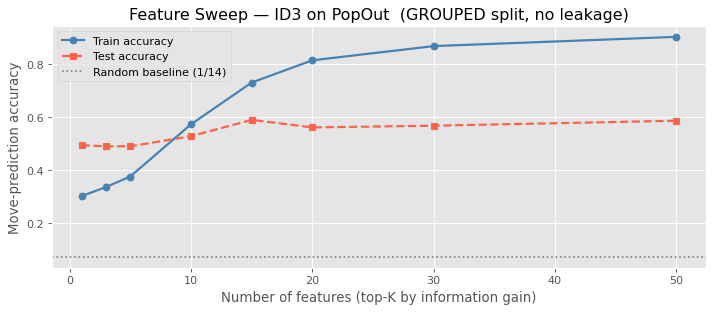

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(sweep_df['K'], sweep_df['Train'], 'o-', label='Train accuracy', color='steelblue')
plt.plot(sweep_df['K'], sweep_df['Test'],  's--', label='Test accuracy',  color='tomato')
plt.axhline(1/df[TARGET].nunique(), color='gray', linestyle=':', label='Random baseline')
plt.xlabel('Number of features (top-K by information gain)')
plt.ylabel('Move-prediction accuracy')
plt.title('Feature Sweep — ID3 on PopOut')
plt.legend()
plt.tight_layout()
plt.show()

### Feature-sweep discussion (GROUPED split, no leakage)

Three patterns stand out in the curve above:

1. **Train accuracy grows nearly linearly** with K (30 % → 90 %), confirming that the
   tree has plenty of *capacity* to memorise the training set.
2. **Test accuracy reaches its plateau around K ≈ 15** at ≈ 58–59 %, and adding the
   remaining 35 features keeps it within a 2 pp band. The marginal value of features
   beyond the top 15 (centre, phase, central column cells, opponent threats) is
   essentially zero for generalisation.
3. **At very low K (1–5), test accuracy is actually higher than train accuracy.**
   This is an artefact of proven-position oversampling: the train set distribution is
   *not* the natural data distribution, while the test set is. A shallow tree learns
   a robust rule (e.g. always answer based on `center_me`) that happens to fit the
   natural test distribution slightly better than the artificially inflated train one.
   The phenomenon disappears as K grows and the tree begins to memorise specific
   board configurations.

The train/test gap at K = 50 is **+31 pp** (90 % vs 59 %), a clear *high-bias /
high-variance* regime: the tree memorises the training rows but only a fraction of
the underlying signal transfers to unseen states. To meaningfully exceed ≈ 60 %
test accuracy with the current dataset one would need richer engineered features,
ensembling (e.g. random forest), or proper post-pruning — none of which is in
scope for this assignment.

Even so, **≈ 59 % is well above the trivial baselines**: random prediction over 14
classes gives 7.1 %, always-predict-`drop_3` gives ≈ 28 %. The tree is therefore
learning meaningful structure; it is just substantially less than the BUGGY split's
inflated 88 % figure suggested.

## 5. Win-Rate Evaluation

The ID3 tree is evaluated against two engine families at multiple iteration counts:

| Engine | Iterations tested | Notes |
|---|---|---|
| **FlatNumbaMCTS** | 100 · 500 · 1 000 · 5 000 · 10 000 | Standard MCTS, no proof propagation |
| **FlatNumbaSolverMCTS** | 1 000 · 5 000 · 10 000 · 50 000 · 100 000 | MCTS-Solver, exits when proven & all root moves tried |

100 games per configuration, alternating sides for balance.
Moves are selected through the full `ID3Agent`/`ID3AgentRaw` wrappers,
which include the `_forced_move` rule layer (immediate win / block) before
consulting the tree.

In [ ]:
import pickle, gc

import ctypes as _ct
# Free memory from earlier cells before heavy training
_gns = globals()
for _v in ['df_str', 'df_str_train', 'df_train', 'df_test', 'df_train_aug',
           'clf_full', 'clf_k', 'sweep_df', 'sweep_results', '_ranker', 'ig_scores', 'ranked_features']:
    _gns.pop(_v, None)
del _gns
gc.collect()
try: _ct.cdll.LoadLibrary('libc.so.6').malloc_trim(0)
except: pass

PICKLE_PATH     = Path(f'../data/generated/{VERSION}/id3_model.pkl')
PICKLE_RAW_PATH = Path(f'../data/generated/{VERSION}/id3_model_raw.pkl')

_EXCLUDE_RAW = {'best_move', 'is_proven', 'threats_me', 'threats_opp',
                'center_me', 'center_opp', 'phase', 'can_win', 'opp_wins_next'}
RAW_OVERSAMPLE = 4
RAW_DEPTH      = 20

def _filter_can_win(df):
    """Drop positions where can_win=1 — _forced_move handles those during play."""
    if 'can_win' not in df.columns:
        return df
    return df[df['can_win'] != 1].reset_index(drop=True)

# ── ID3 with engineered features ─────────────────────────────────────────────
if PICKLE_PATH.exists():
    print(f'Loading clf_game from {PICKLE_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_PATH, 'rb') as f:
        clf_game = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print('Training clf_game on full dataset (features, depth=15, 4x proven oversampling)...')
    _df = _filter_can_win(df.copy())
    print(f'  After can_win=1 filter: {len(_df):,} rows')
    _feat_cols = [c for c in _df.columns if c not in ('best_move', 'is_proven')]
    if 'is_proven' in _df.columns:
        _proven = _df[_df['is_proven'] == 1]
        _df = pd.concat([_df] + [_proven] * 4, ignore_index=True)
        del _proven
    for c in _feat_cols: _df[c] = _df[c].astype(str)
    _df['best_move'] = _df['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game = ID3Classifier(max_depth=15)
    clf_game.fit(_df[_feat_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df; gc.collect()
    try: _ct.cdll.LoadLibrary('libc.so.6').malloc_trim(0)
    except: pass
    PICKLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_PATH, 'wb') as f: pickle.dump(clf_game, f)
    print(f'  Saved to {PICKLE_PATH}')

# ── ID3 Raw (raw cells only, heavy proven oversampling) ───────────────────────
if PICKLE_RAW_PATH.exists():
    print(f'\nLoading clf_game_raw from {PICKLE_RAW_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_RAW_PATH, 'rb') as f:
        clf_game_raw = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print(f'\nTraining clf_game_raw (raw cells, depth={RAW_DEPTH}, {RAW_OVERSAMPLE}x proven)...')
    _df_raw = _filter_can_win(df.copy())
    print(f'  After can_win=1 filter: {len(_df_raw):,} rows')
    _raw_cols = [c for c in _df_raw.columns if c not in _EXCLUDE_RAW]
    if 'is_proven' in _df_raw.columns:
        _proven = _df_raw[_df_raw['is_proven'] == 1]
        _df_raw = pd.concat([_df_raw] + [_proven] * RAW_OVERSAMPLE, ignore_index=True)
        del _proven
    for c in _raw_cols: _df_raw[c] = _df_raw[c].astype(str)
    _df_raw['best_move'] = _df_raw['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game_raw = ID3Classifier(max_depth=RAW_DEPTH)
    clf_game_raw.fit(_df_raw[_raw_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df_raw; gc.collect()
    PICKLE_RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_RAW_PATH, 'wb') as f: pickle.dump(clf_game_raw, f)
    print(f'  Saved to {PICKLE_RAW_PATH}')

In [3]:
from src.mcts.optimized.numba_mcts import warmup, FlatNumbaMCTS
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup()   # covers FlatNumbaMCTS, NumbaMCTS, FlatNumbaSolverMCTS and all kernels
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.3 s


In [4]:
from src.decision_tree.id3_agent import ID3Agent
from src.decision_tree.id3_agent_raw import ID3AgentRaw

def _make_tree_agent(clf, raw=False):
    """Wrap an already-trained classifier in the agent class (includes _forced_move)."""
    agent = (ID3AgentRaw() if raw else ID3Agent())
    agent._classifier = clf
    return agent

def play_one_game(tree_agent, mcts_agent, tree_plays_as, mcts_iterations, max_moves=120):
    """Play one game. Returns +1 (tree wins), -1 (tree loses), 0 (draw)."""
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        if mover == tree_plays_as:
            move = tree_agent.run(board)
        else:
            move = mcts_agent.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0

In [5]:
EVAL_GAMES = 100

CONFIGS = {
    'FlatNumbaMCTS':       [100, 500, 1_000, 5_000, 10_000],
    'FlatNumbaSolverMCTS': [1_000, 5_000, 10_000, 50_000, 100_000],
}

TREE_MODELS = {
    'ID3 (features)': _make_tree_agent(clf_game,     raw=False),
    'ID3 Raw':        _make_tree_agent(clf_game_raw, raw=True),
}

eval_results = {}

t0 = time.perf_counter()
for model_name, tree_agent in TREE_MODELS.items():
    print(f'\n── {model_name} ──')
    for engine_name, iter_list in CONFIGS.items():
        for iters in iter_list:
            mcts_agent = (FlatNumbaMCTS(max_nodes=iters + 256)
                          if engine_name == 'FlatNumbaMCTS'
                          else FlatNumbaSolverMCTS(max_nodes=iters + 256))
            wins = losses = draws = 0
            for i in range(EVAL_GAMES):
                r = play_one_game(tree_agent, mcts_agent, 1 if i % 2 == 0 else 2, iters)
                if r == 1:    wins   += 1
                elif r == -1: losses += 1
                else:         draws  += 1
            eval_results[(model_name, engine_name, iters)] = (wins, losses, draws)
            wr = wins / EVAL_GAMES
            print(f'  {engine_name:22s}  {iters:7,d} iter  ->  {wr:5.1%}  '
                  f'({wins}W / {losses}L / {draws}D)')
        print()

print(f'Total evaluation time: {time.perf_counter() - t0:.1f} s')


── ID3 (features) ──
  FlatNumbaMCTS               100 iter  ->  89.0%  (89W / 11L / 0D)
  FlatNumbaMCTS               500 iter  ->  69.0%  (69W / 31L / 0D)
  FlatNumbaMCTS             1,000 iter  ->  50.0%  (50W / 50L / 0D)
  FlatNumbaMCTS             5,000 iter  ->  37.0%  (37W / 63L / 0D)
  FlatNumbaMCTS            10,000 iter  ->  27.0%  (27W / 73L / 0D)

  FlatNumbaSolverMCTS       1,000 iter  ->  46.0%  (46W / 54L / 0D)
  FlatNumbaSolverMCTS       5,000 iter  ->  32.0%  (32W / 68L / 0D)
  FlatNumbaSolverMCTS      10,000 iter  ->  35.0%  (35W / 65L / 0D)
  FlatNumbaSolverMCTS      50,000 iter  ->  54.0%  (54W / 46L / 0D)
  FlatNumbaSolverMCTS     100,000 iter  ->  51.0%  (51W / 49L / 0D)


── ID3 Raw ──
  FlatNumbaMCTS               100 iter  ->  94.0%  (94W / 6L / 0D)
  FlatNumbaMCTS               500 iter  ->  66.0%  (66W / 33L / 1D)
  FlatNumbaMCTS             1,000 iter  ->  62.0%  (62W / 38L / 0D)
  FlatNumbaMCTS             5,000 iter  ->  51.0%  (51W / 49L / 0D)
  FlatNumb

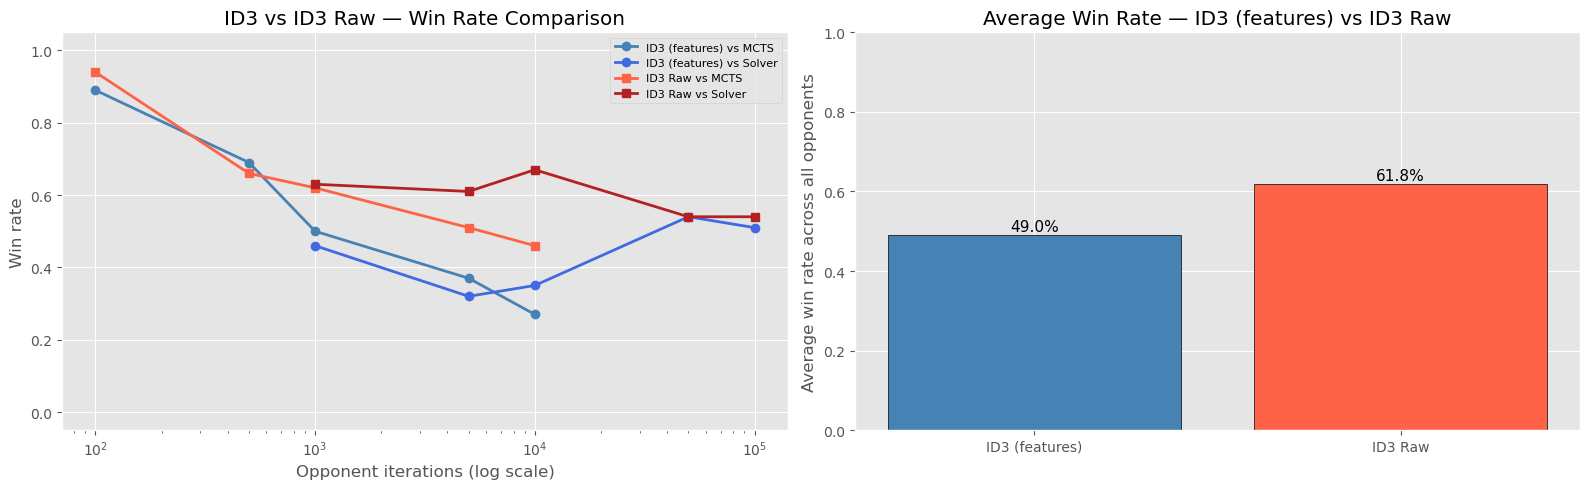


Model                 Opponent engine         Iterations     Win%     W     L     D
---------------------------------------------------------------------------
ID3 (features)        FlatNumbaMCTS                  100    89.0%    89    11     0
ID3 (features)        FlatNumbaMCTS                  500    69.0%    69    31     0
ID3 (features)        FlatNumbaMCTS                1,000    50.0%    50    50     0
ID3 (features)        FlatNumbaMCTS                5,000    37.0%    37    63     0
ID3 (features)        FlatNumbaMCTS               10,000    27.0%    27    73     0
ID3 (features)        FlatNumbaSolverMCTS          1,000    46.0%    46    54     0
ID3 (features)        FlatNumbaSolverMCTS          5,000    32.0%    32    68     0
ID3 (features)        FlatNumbaSolverMCTS         10,000    35.0%    35    65     0
ID3 (features)        FlatNumbaSolverMCTS         50,000    54.0%    54    46     0
ID3 (features)        FlatNumbaSolverMCTS        100,000    51.0%    51    49     0

In [6]:
ENGINE_SHORT = {'FlatNumbaMCTS': 'MCTS', 'FlatNumbaSolverMCTS': 'Solver'}
MODEL_COLORS = {'ID3 (features)': {'FlatNumbaMCTS': 'steelblue', 'FlatNumbaSolverMCTS': 'royalblue'},
                'ID3 Raw':        {'FlatNumbaMCTS': 'tomato',    'FlatNumbaSolverMCTS': 'firebrick'}}
MODEL_MARKERS = {'ID3 (features)': 'o', 'ID3 Raw': 's'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for model_name in TREE_MODELS:
    for engine_name, iter_list in CONFIGS.items():
        win_rates = [eval_results[(model_name, engine_name, it)][0] / EVAL_GAMES
                     for it in iter_list]
        axes[0].plot(iter_list, win_rates,
                     marker=MODEL_MARKERS[model_name], linestyle='-',
                     color=MODEL_COLORS[model_name][engine_name], linewidth=2,
                     label=f'{model_name} vs {ENGINE_SHORT[engine_name]}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Opponent iterations (log scale)')
axes[0].set_ylabel('Win rate')
axes[0].set_title('ID3 vs ID3 Raw — Win Rate Comparison')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=8)

model_names = list(TREE_MODELS.keys())
avg_wr = [
    np.mean([eval_results[(m, eng, it)][0] / EVAL_GAMES
             for eng, iters in CONFIGS.items() for it in iters])
    for m in model_names
]
bar_colors = ['steelblue', 'tomato']
axes[1].bar(model_names, avg_wr, color=bar_colors, edgecolor='black')
for i, v in enumerate(avg_wr):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)
axes[1].set_ylabel('Average win rate across all opponents')
axes[1].set_title('Average Win Rate — ID3 (features) vs ID3 Raw')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f'\n{"Model":<20}  {"Opponent engine":<22}  {"Iterations":>10}  {"Win%":>7}  {"W":>4}  {"L":>4}  {"D":>4}')
print('-' * 75)
for model_name in TREE_MODELS:
    for engine_name, iter_list in CONFIGS.items():
        for it in iter_list:
            w, l, d = eval_results[(model_name, engine_name, it)]
            print(f'{model_name:<20}  {engine_name:<22}  {it:>10,}  '
                  f'{w/EVAL_GAMES:>7.1%}  {w:>4}  {l:>4}  {d:>4}')
    print()

## 6. Cross-Version Comparison

Load the trained models from all four dataset versions and evaluate each against
`FlatNumbaSolverMCTS` at 1 000 and 10 000 iterations (50 games each, alternating sides).

| Version | Dataset size | Notes |
|---|---|---|
| v1 | 3 000 games, 100 k iter oracle | Baseline |
| v2 | 5 000 games, 100 k iter oracle | Larger baseline |
| v3 | 5 000 games, tiered blunders | Diversity via blunder tiers |
| v4 | 75 000 games, tiered blunders | Scale-up; raw x4 oversampling (RAM limit) |

In [ ]:
import pickle, gc, time
import ctypes as _ct
from pathlib import Path

from src.decision_tree.id3_agent import ID3Agent
from src.decision_tree.id3_agent_raw import ID3AgentRaw

_ROOT = Path('..')

def _load_agent(pkl_path, raw=False):
    agent = ID3AgentRaw() if raw else ID3Agent()
    with open(pkl_path, 'rb') as f:
        agent._classifier = pickle.load(f)
    return agent

VERSION_AGENTS = {
    'v1 (3k)   feat': _load_agent(_ROOT / 'data/generated/v1_3000games_100k/id3_model.pkl',     raw=False),
    'v1 (3k)   raw':  _load_agent(_ROOT / 'data/generated/v1_3000games_100k/id3_model_raw.pkl', raw=True),
    'v2 (5k)   feat': _load_agent(_ROOT / 'data/generated/v2_5000games_100k/id3_model.pkl',     raw=False),
    'v2 (5k)   raw':  _load_agent(_ROOT / 'data/generated/v2_5000games_100k/id3_model_raw.pkl', raw=True),
    'v3 tiered feat': _load_agent(_ROOT / 'data/generated/v3_5000games_tiered/id3_model.pkl',   raw=False),
    'v3 tiered raw':  _load_agent(_ROOT / 'data/generated/v3_5000games_tiered/id3_model_raw.pkl',raw=True),
    'v4 (75k)  feat': _load_agent(_ROOT / 'data/generated/v4_75k_100k/id3_model.pkl',           raw=False),
    'v4 (75k)  raw':  _load_agent(_ROOT / 'data/generated/v4_75k_100k/id3_model_raw.pkl',       raw=True),
}
print('All version models loaded.')

In [ ]:
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move

CROSS_GAMES  = 50
CROSS_ITERS  = [1_000, 10_000]

def _play_cross(tree_agent, mcts_iters, max_moves=120):
    wins = losses = draws = 0
    for i in range(CROSS_GAMES):
        board  = PopOutBoard()
        tree_p = 1 if i % 2 == 0 else 2
        mcts   = FlatNumbaSolverMCTS(max_nodes=mcts_iters + 256)
        result = 0
        for _ in range(max_moves):
            legal = board.legal_moves()
            if not legal:
                result = 0; break
            mover = board.current_player
            move  = tree_agent.run(board) if mover == tree_p else mcts.run(board, iterations=mcts_iters)
            board.apply_move(move)
            winner = evaluate_after_move(board, mover=mover)
            if winner:
                result = 1 if winner == tree_p else -1
                break
        if result == 1:   wins   += 1
        elif result == -1: losses += 1
        else:              draws  += 1
    return wins, losses, draws

cross_results = {}
t0 = time.perf_counter()
print(f'{"Model":<22}  {"Iters":>7}  {"Win%":>6}  {"W":>3}  {"L":>3}  {"D":>3}')
print('-' * 55)
for model_name, agent in VERSION_AGENTS.items():
    for iters in CROSS_ITERS:
        w, l, d = _play_cross(agent, iters)
        cross_results[(model_name, iters)] = (w, l, d)
        print(f'{model_name:<22}  {iters:>7,}  {w/CROSS_GAMES:>6.1%}  {w:>3}  {l:>3}  {d:>3}')
    print()
print(f'Done in {time.perf_counter()-t0:.1f} s')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Average win rate per model across both iter counts
models  = list(VERSION_AGENTS.keys())
avg_wrs = [
    np.mean([cross_results[(m, it)][0] / CROSS_GAMES for it in CROSS_ITERS])
    for m in models
]

feat_mask = ['feat' in m for m in models]
raw_mask  = ['raw'  in m for m in models]
colors    = ['steelblue' if f else 'tomato' for f in feat_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Bar chart: average win rate per model ────────────────────────────────────
bars = axes[0].bar(models, avg_wrs, color=colors, edgecolor='black')
for bar, v in zip(bars, avg_wrs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{v:.1%}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Average win rate vs FlatNumbaSolverMCTS')
axes[0].set_title('Cross-Version Average Win Rate (1k & 10k iter)')
axes[0].tick_params(axis='x', rotation=30)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='steelblue', label='features'),
                         Patch(facecolor='tomato',    label='raw')], fontsize=9)

# ── Line chart: win rate per iter count, feat vs raw ─────────────────────────
version_labels = ['v1 (3k)', 'v2 (5k)', 'v3 tiered', 'v4 (75k)']
for iters, style in zip(CROSS_ITERS, ['-', '--']):
    feat_wrs = [cross_results[(m, iters)][0] / CROSS_GAMES for m in models if 'feat' in m]
    raw_wrs  = [cross_results[(m, iters)][0] / CROSS_GAMES for m in models if 'raw'  in m]
    axes[1].plot(version_labels, feat_wrs, 'o' + style, color='steelblue',
                 label=f'feat  {iters:,} iter', linewidth=2)
    axes[1].plot(version_labels, raw_wrs,  's' + style, color='tomato',
                 label=f'raw   {iters:,} iter', linewidth=2)

axes[1].set_ylim(-0.05, 1.05)
axes[1].set_ylabel('Win rate vs FlatNumbaSolverMCTS')
axes[1].set_title('Win Rate by Dataset Version')
axes[1].legend(fontsize=8)
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig('../data/figures/cross_version_winrate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to data/figures/cross_version_winrate.png')